MATALI HMM ROUTING SIMULATION - 20 CALLS, 5 HOSPITALS, GADAG DISTRICT

Call # 1 | [RED] head    | T=  2.5min
  -> SELECTED: GIMS Medical College
     ETA=12.4min | P(Avail)=0.605 | Cap=1.0 | U=0.1073
     [GIMS Medical College U=+0.1073 d=0] <--
     [District Hospital Ga U=-0.2307 d=0]
     [Private Trauma Cente U=-0.3145 d=0]
     [PHC Lakkundi         U=-0.9604 d=0]
     [SDM Medical Dharwad  U=-3.2298 d=0]

Call # 2 | [YLW] limb    | T=  7.0min
  -> SELECTED: District Hospital Gadag
     ETA=8.1min | P(Avail)=0.545 | Cap=1.0 | U=0.4235
     [District Hospital Ga U=+0.4235 d=0] <--
     [GIMS Medical College U=+0.4158 d=1]
     [Private Trauma Cente U=+0.3729 d=0]
     [PHC Lakkundi         U=-0.2366 d=0]
     [SDM Medical Dharwad  U=-1.0914 d=0]

Call # 3 | [RED] chest   | T= 18.7min
  -> SELECTED: GIMS Medical College
     ETA=7.4min | P(Avail)=0.614 | Cap=1.0 | U=0.3165
     [GIMS Medical College U=+0.3165 d=1] <--
     [Private Trauma Cente U=+0.0573 d=0]
     [District Hospital

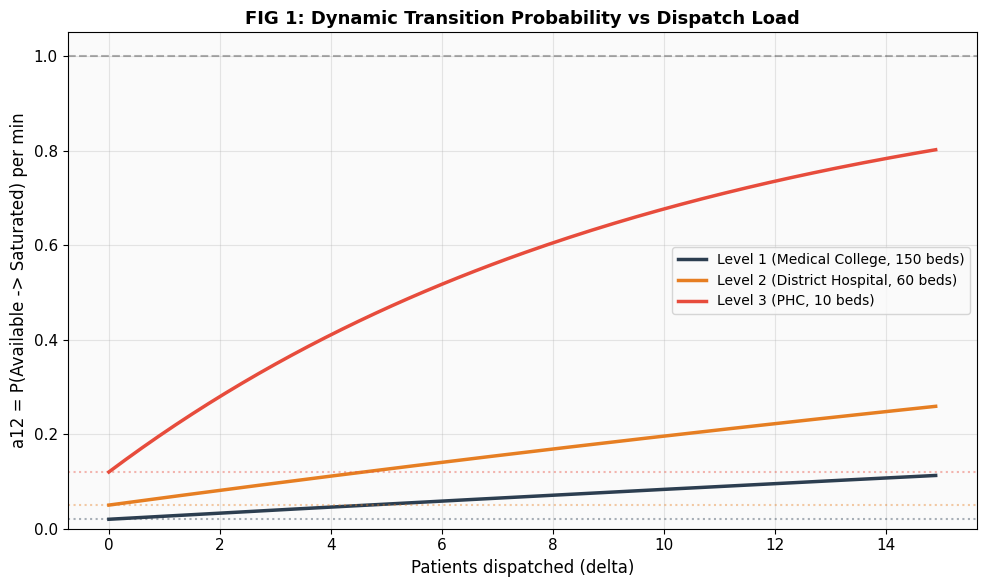

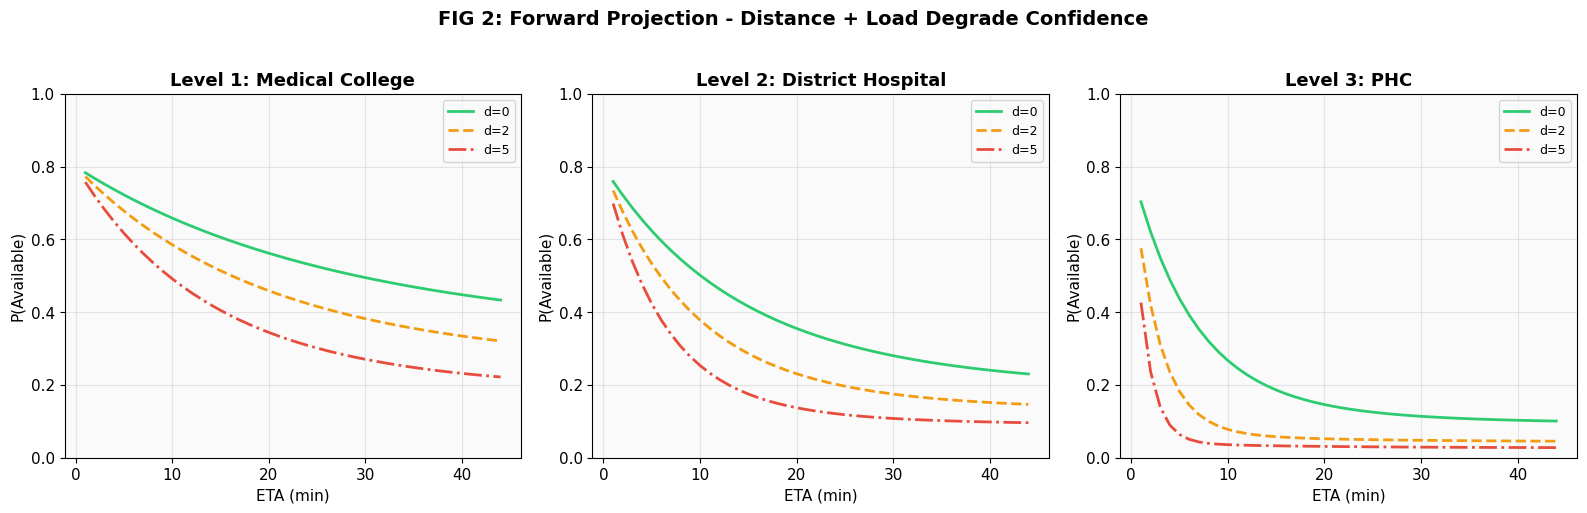

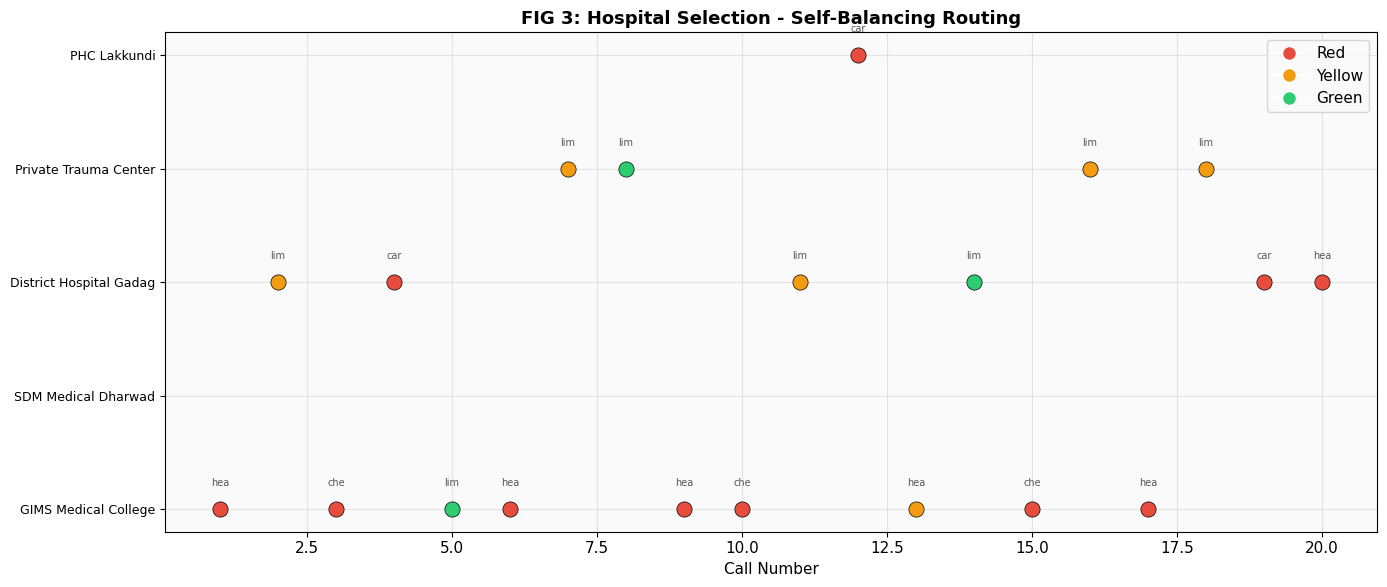

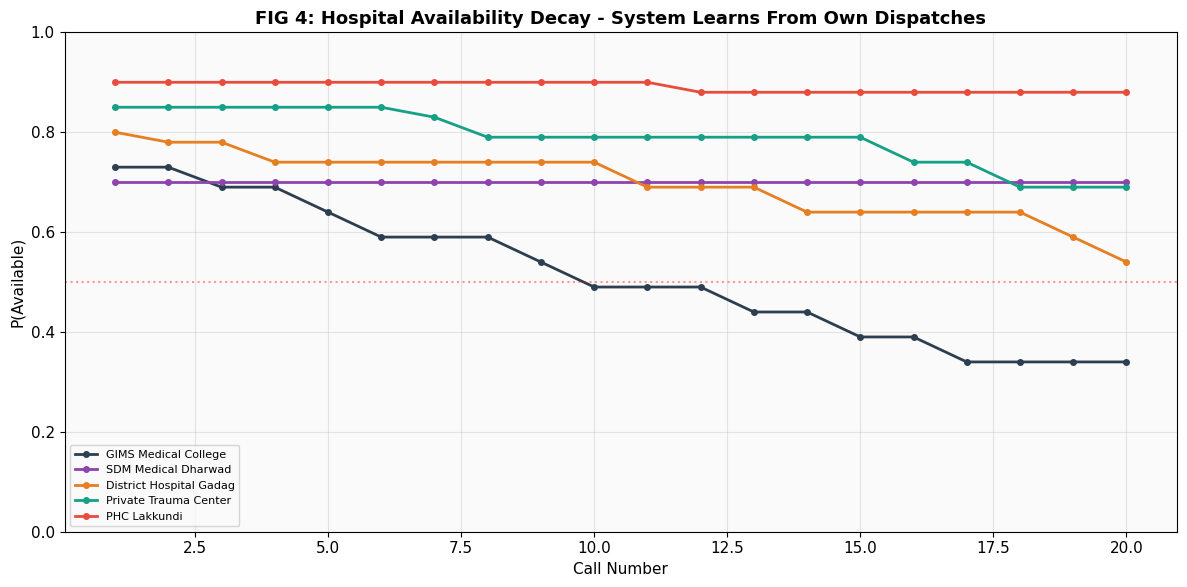

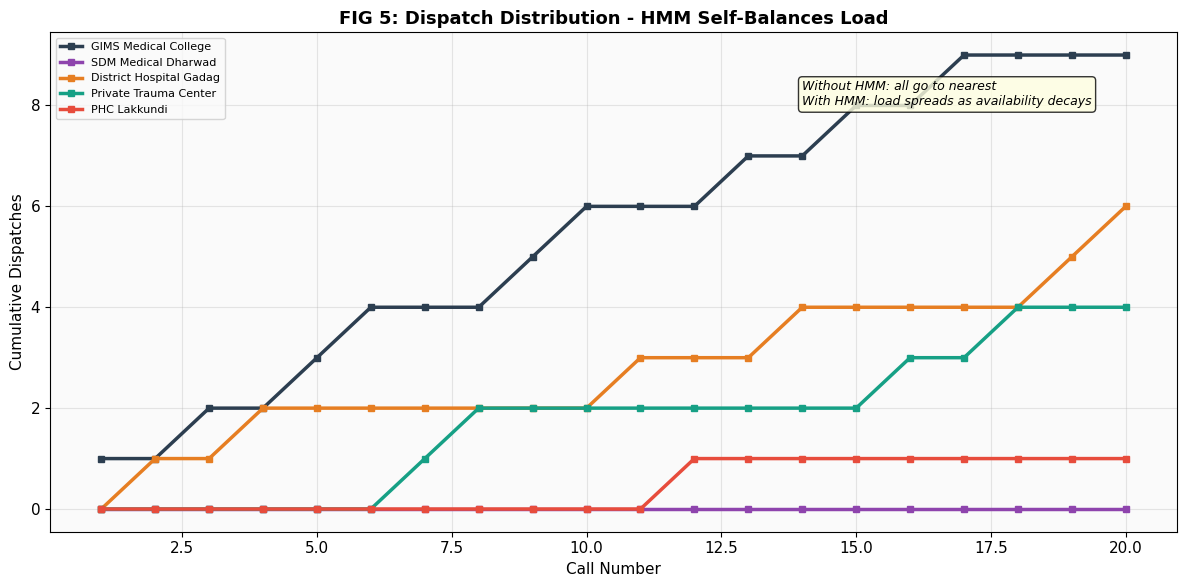

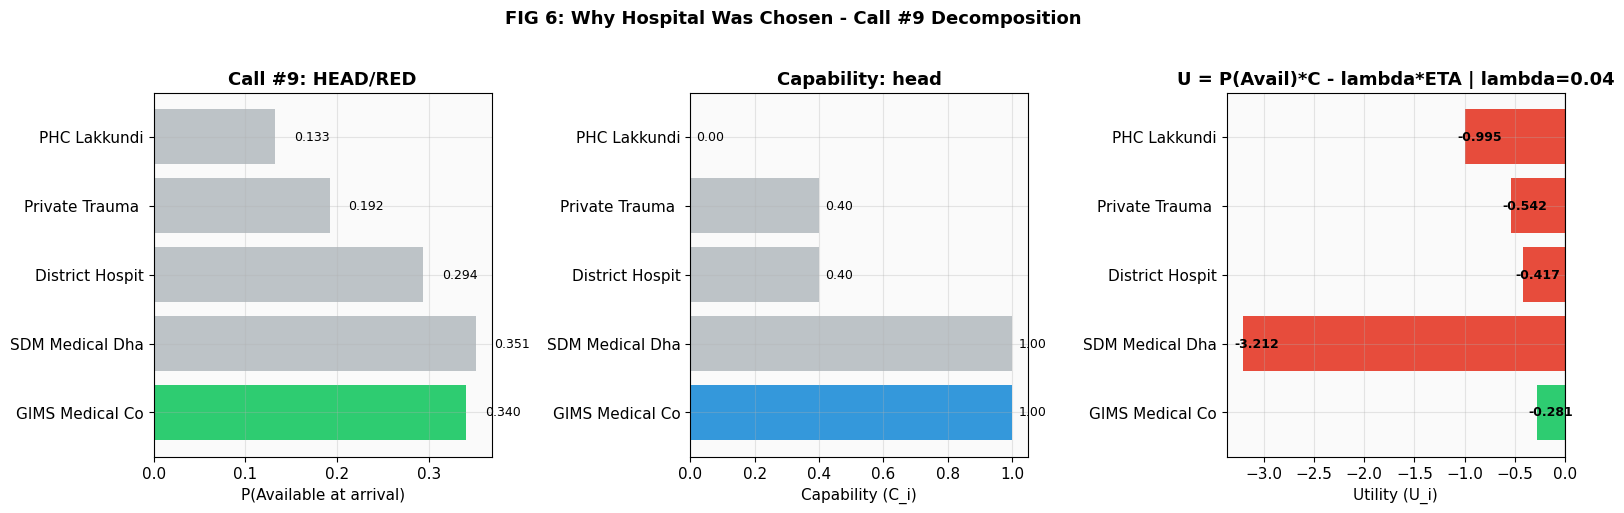

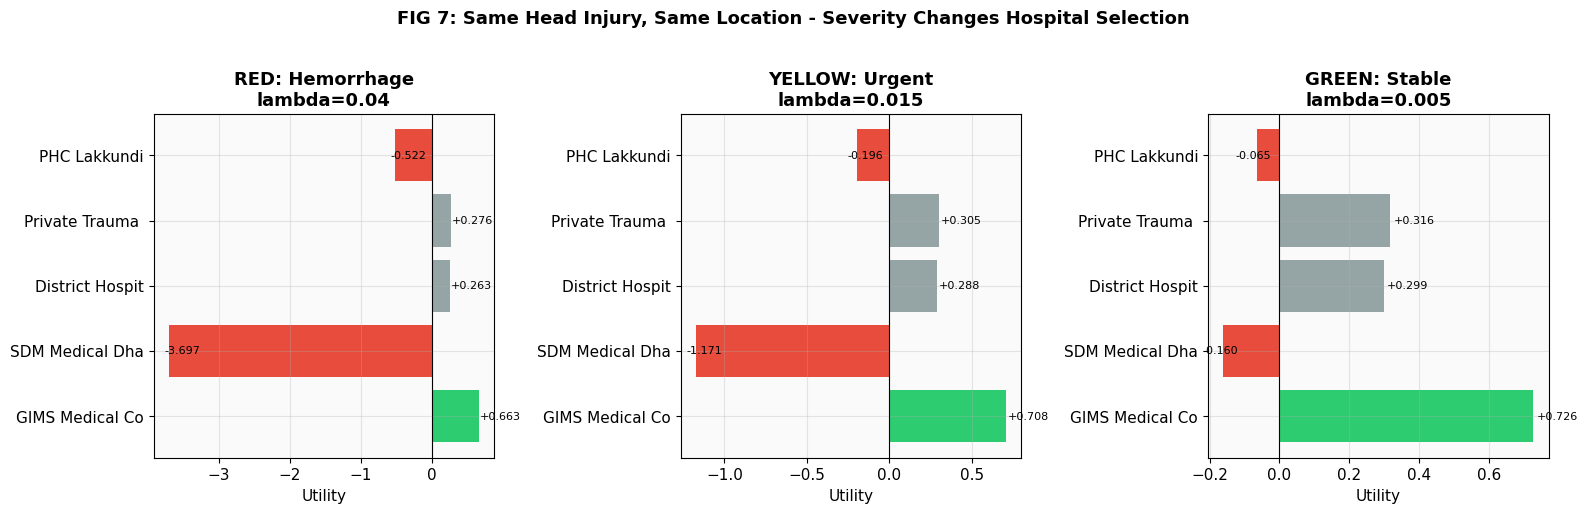


SIMULATION COMPLETE - 7 FIGURES GENERATED

KEY RESULTS:
  Fig 1: PHC saturates after ~3 dispatches; Medical College absorbs 10+
  Fig 2: Distance DEGRADES confidence (matrix exponentiation effect)
  Fig 3: System routes to DIFFERENT hospitals per injury + severity
  Fig 4: Availability belief drops as system dispatches to a hospital
  Fig 5: HMM naturally LOAD BALANCES across hospitals
  Fig 6: Full decomposition of WHY a specific hospital was chosen
  Fig 7: Same injury, different severity -> different optimal hospital



In [6]:
"""
Matali - Hidden Markov Model Hospital Routing Simulation
=============================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

STATES = ['Available', 'Saturated', 'Diverting']

# ============================================================
# DATA STRUCTURES
# ============================================================
@dataclass
class Hospital:
    name: str
    lat: float
    lng: float
    tier: int
    beds: int
    capabilities: dict
    a12_base: float = 0.0
    k: float = 0.0
    dispatch_count: int = 0
    state_vector: np.ndarray = field(default_factory=lambda: np.array([0.8, 0.15, 0.05]))

    def __post_init__(self):
        tier_base = {1: 0.02, 2: 0.05, 3: 0.12}
        self.a12_base = tier_base.get(self.tier, 0.05)
        self.k = 1.0 / max(self.beds, 1)

@dataclass
class EmergencyCall:
    call_id: int
    lat: float
    lng: float
    injury_type: str
    severity: str
    timestamp_min: float

# ============================================================
# CORE MATH
# ============================================================

def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlng = np.radians(lng2 - lng1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlng/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def estimate_eta(distance_km, avg_speed_kmh=40):
    return (distance_km / avg_speed_kmh) * 60

def compute_dynamic_a12(a12_base, k, delta):
    """CORRECTED: a12 = a12_base + (1 - a12_base)*(1 - e^{-k*delta}). Always in [a12_base, 1]."""
    return a12_base + (1 - a12_base) * (1 - np.exp(-k * delta))

def build_transition_matrix(hospital):
    delta = hospital.dispatch_count
    a12 = compute_dynamic_a12(hospital.a12_base, hospital.k, delta)
    a13 = 0.005
    a11 = max(1 - a12 - a13, 0.0)
    a21 = 0.02
    a23 = min(0.03 + 0.02 * delta, 0.3)
    a22 = max(1 - a21 - a23, 0.0)
    a31 = 0.005
    a32 = 0.03
    a33 = max(1 - a31 - a32, 0.0)
    A = np.array([[a11, a12, a13], [a21, a22, a23], [a31, a32, a33]])
    for i in range(3):
        A[i] /= A[i].sum()
    return A

def forward_project(state_vector, A, delta_t):
    """P(X_{t+dt}) = P(X_t) . A^{dt}"""
    A_power = np.linalg.matrix_power(A, max(delta_t, 1))
    projected = state_vector @ A_power
    projected = np.clip(projected, 0, 1)
    projected /= projected.sum()
    return projected

def capability_score(hospital, injury_type):
    caps = hospital.capabilities
    scores = {
        'head': (1.0 if caps.get('neurosurgery') and caps.get('ct_scan') and caps.get('blood_bank')
                 else 0.4 if caps.get('general_surgery') and caps.get('blood_bank')
                 else 0.1 if caps.get('general_surgery') else 0.0),
        'chest': (1.0 if caps.get('thoracic_surgery') and caps.get('blood_bank') and caps.get('icu')
                  else 0.5 if caps.get('general_surgery') and caps.get('icu') else 0.1),
        'limb': (1.0 if caps.get('orthopedics') and caps.get('blood_bank')
                 else 0.6 if caps.get('general_surgery') else 0.2),
        'cardiac': (1.0 if caps.get('cath_lab') and caps.get('icu')
                    else 0.4 if caps.get('icu') else 0.1),
    }
    return scores.get(injury_type, 0.5)

def severity_lambda(severity):
    return {'red': 0.04, 'yellow': 0.015, 'green': 0.005}[severity]

def compute_utility(hospital, call):
    dist = haversine_km(call.lat, call.lng, hospital.lat, hospital.lng)
    eta = estimate_eta(dist)
    A = build_transition_matrix(hospital)
    projected = forward_project(hospital.state_vector, A, int(eta))
    p_available = projected[0]
    C = capability_score(hospital, call.injury_type)
    lam = severity_lambda(call.severity)
    U = p_available * C - lam * eta
    return {
        'hospital': hospital.name, 'distance_km': round(dist, 1),
        'eta_min': round(eta, 1), 'p_available': round(p_available, 4),
        'p_saturated': round(projected[1], 4), 'p_diverting': round(projected[2], 4),
        'capability': round(C, 2), 'lambda': lam, 'utility': round(U, 4),
        'dispatch_count': hospital.dispatch_count,
    }

# ============================================================
# SIMULATION DATA
# ============================================================

def create_hospitals():
    return [
        Hospital("GIMS Medical College", 15.4307, 75.6370, 1, 150,
                 {'neurosurgery': True, 'general_surgery': True, 'orthopedics': True,
                  'blood_bank': True, 'ct_scan': True, 'icu': True,
                  'thoracic_surgery': True, 'cath_lab': False},
                 state_vector=np.array([0.75, 0.18, 0.07])),
        Hospital("SDM Medical Dharwad", 15.4589, 75.0078, 1, 200,
                 {'neurosurgery': True, 'general_surgery': True, 'orthopedics': True,
                  'blood_bank': True, 'ct_scan': True, 'icu': True,
                  'thoracic_surgery': True, 'cath_lab': True},
                 state_vector=np.array([0.70, 0.20, 0.10])),
        Hospital("District Hospital Gadag", 15.4180, 75.6290, 2, 60,
                 {'neurosurgery': False, 'general_surgery': True, 'orthopedics': True,
                  'blood_bank': True, 'ct_scan': True, 'icu': True,
                  'thoracic_surgery': False, 'cath_lab': False},
                 state_vector=np.array([0.80, 0.15, 0.05])),
        Hospital("Private Trauma Center", 15.4250, 75.6400, 2, 30,
                 {'neurosurgery': False, 'general_surgery': True, 'orthopedics': True,
                  'blood_bank': True, 'ct_scan': False, 'icu': True,
                  'thoracic_surgery': False, 'cath_lab': False},
                 state_vector=np.array([0.85, 0.10, 0.05])),
        Hospital("PHC Lakkundi", 15.3900, 75.7100, 3, 10,
                 {'neurosurgery': False, 'general_surgery': False, 'orthopedics': False,
                  'blood_bank': False, 'ct_scan': False, 'icu': False,
                  'thoracic_surgery': False, 'cath_lab': False},
                 state_vector=np.array([0.90, 0.08, 0.02])),
    ]

def create_calls():
    np.random.seed(42)
    injuries =   ['head','limb','chest','cardiac','limb','head','limb','limb',
                  'head','chest','limb','cardiac','head','limb','chest',
                  'limb','head','limb','cardiac','head']
    severities = ['red','yellow','red','red','green','red','yellow','green',
                  'red','red','yellow','red','yellow','green','red',
                  'yellow','red','yellow','red','red']
    times = sorted(np.random.uniform(0, 120, 20))
    calls = []
    for i in range(20):
        calls.append(EmergencyCall(
            i+1, 15.40 + np.random.uniform(-0.05, 0.05),
            75.62 + np.random.uniform(-0.08, 0.08),
            injuries[i], severities[i], times[i]))
    return calls

# ============================================================
# RUN SIMULATION
# ============================================================

hospitals = create_hospitals()
calls = create_calls()
results = []
all_utilities = []
state_history = {h.name: [] for h in hospitals}
dispatch_history = {h.name: [] for h in hospitals}

print("=" * 90)
print("MATALI HMM ROUTING SIMULATION - 20 CALLS, 5 HOSPITALS, GADAG DISTRICT")
print("=" * 90)

for call in calls:
    call_utils = [compute_utility(h, call) for h in hospitals]
    best = max(call_utils, key=lambda x: x['utility'])
    results.append({'call': call, 'selected': best['hospital'], 'utilities': call_utils, 'best': best})
    all_utilities.append(call_utils)

    for h in hospitals:
        if h.name == best['hospital']:
            h.dispatch_count += 1
            shift = min(0.05, 0.02 * h.dispatch_count)
            h.state_vector[0] = max(h.state_vector[0] - shift, 0.1)
            h.state_vector[1] = min(h.state_vector[1] + shift * 0.7, 0.8)
            h.state_vector[2] = min(h.state_vector[2] + shift * 0.3, 0.5)
            h.state_vector /= h.state_vector.sum()
        state_history[h.name].append(h.state_vector.copy())
        dispatch_history[h.name].append(h.dispatch_count)

    sev_emoji = {'red': '[RED]', 'yellow': '[YLW]', 'green': '[GRN]'}
    print(f"\nCall #{call.call_id:2d} | {sev_emoji[call.severity]} {call.injury_type:7s} | T={call.timestamp_min:5.1f}min")
    print(f"  -> SELECTED: {best['hospital']}")
    print(f"     ETA={best['eta_min']}min | P(Avail)={best['p_available']:.3f} | Cap={best['capability']} | U={best['utility']:.4f}")
    for u in sorted(call_utils, key=lambda x: -x['utility']):
        marker = " <--" if u['hospital'] == best['hospital'] else ""
        print(f"     [{u['hospital'][:20]:20s} U={u['utility']:+.4f} d={u['dispatch_count']}]{marker}")

print("\n" + "=" * 90)
print("FINAL DISPATCH DISTRIBUTION")
print("=" * 90)
for h in hospitals:
    bar = "#" * h.dispatch_count + "." * (20 - h.dispatch_count)
    print(f"  {h.name:30s} | {bar} | {h.dispatch_count} patients")

# ============================================================
# FIGURE 1: Decay Function
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
delta_range = np.arange(0, 15, 0.1)
for label, a12b, k, color in [
    ("Level 1 (Medical College, 150 beds)", 0.02, 1/150, '#2c3e50'),
    ("Level 2 (District Hospital, 60 beds)", 0.05, 1/60, '#e67e22'),
    ("Level 3 (PHC, 10 beds)", 0.12, 1/10, '#e74c3c')]:
    ax1.plot(delta_range, [compute_dynamic_a12(a12b, k, d) for d in delta_range],
             linewidth=2.5, label=label, color=color)
    ax1.axhline(y=a12b, color=color, linestyle=':', alpha=0.4)
ax1.set_xlabel('Patients dispatched (delta)', fontsize=12)
ax1.set_ylabel('a12 = P(Available -> Saturated) per min', fontsize=12)
ax1.set_title('FIG 1: Dynamic Transition Probability vs Dispatch Load')
ax1.legend(fontsize=10); ax1.set_ylim(0, 1.05)
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.savefig('fig1_decay.png', dpi=150); plt.show()

# ============================================================
# FIGURE 2: Forward Projection
# ============================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
for idx, (title, a12b, k_val) in enumerate([
    ("Level 1: Medical College", 0.02, 1/150),
    ("Level 2: District Hospital", 0.05, 1/60),
    ("Level 3: PHC", 0.12, 1/10)]):
    ax = axes2[idx]
    eta_range = range(1, 45)
    for delta, color, ls in [(0, '#2ecc71', '-'), (2, '#f39c12', '--'), (5, '#e74c3c', '-.')]:
        p_avail = []
        for eta in eta_range:
            a12 = compute_dynamic_a12(a12b, k_val, delta)
            A = np.array([[max(1-a12-0.005,0), a12, 0.005],
                          [0.02, 0.95, 0.03], [0.005, 0.03, 0.965]])
            for i in range(3): A[i] /= A[i].sum()
            proj = forward_project(np.array([0.80, 0.15, 0.05]), A, eta)
            p_avail.append(proj[0])
        ax.plot(list(eta_range), p_avail, linewidth=2, color=color, linestyle=ls, label=f'd={delta}')
    ax.set_xlabel('ETA (min)'); ax.set_ylabel('P(Available)'); ax.set_title(title)
    ax.legend(fontsize=9); ax.set_ylim(0, 1)
fig2.suptitle('FIG 2: Forward Projection - Distance + Load Degrade Confidence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig2_projection.png', dpi=150); plt.show()

# ============================================================
# FIGURE 3: Routing Decisions Over 20 Calls
# ============================================================
fig3, ax3 = plt.subplots(figsize=(14, 6))
hospital_names = [h.name for h in create_hospitals()]
name_to_idx = {name: i for i, name in enumerate(hospital_names)}
colors_map = {'red': '#e74c3c', 'yellow': '#f39c12', 'green': '#2ecc71'}
for r in results:
    c = r['call']
    ax3.scatter(c.call_id, name_to_idx[r['selected']], c=colors_map[c.severity],
               s=120, zorder=5, edgecolors='black', linewidth=0.5)
    ax3.annotate(c.injury_type[:3], (c.call_id, name_to_idx[r['selected']] + 0.2),
                fontsize=7, ha='center', color='#555')
ax3.set_yticks(range(len(hospital_names)))
ax3.set_yticklabels([n[:25] for n in hospital_names], fontsize=9)
ax3.set_xlabel('Call Number'); ax3.set_title('FIG 3: Hospital Selection - Self-Balancing Routing')
from matplotlib.lines import Line2D
ax3.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#e74c3c',markersize=10,label='Red'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#f39c12',markersize=10,label='Yellow'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#2ecc71',markersize=10,label='Green'),
], loc='upper right')
plt.tight_layout(); plt.savefig('fig3_routing.png', dpi=150); plt.show()

# ============================================================
# FIGURE 4: Availability Belief Decay
# ============================================================
fig4, ax4 = plt.subplots(figsize=(12, 6))
hcolors = ['#2c3e50', '#8e44ad', '#e67e22', '#16a085', '#e74c3c']
for idx, name in enumerate(state_history.keys()):
    ax4.plot(range(1, 21), [sv[0] for sv in state_history[name]],
            linewidth=2, color=hcolors[idx], label=name[:25], marker='o', markersize=4)
ax4.set_xlabel('Call Number'); ax4.set_ylabel('P(Available)')
ax4.set_title('FIG 4: Hospital Availability Decay - System Learns From Own Dispatches')
ax4.legend(fontsize=8, loc='lower left'); ax4.set_ylim(0, 1)
ax4.axhline(y=0.5, color='red', linestyle=':', alpha=0.4)
plt.tight_layout(); plt.savefig('fig4_decay.png', dpi=150); plt.show()

# ============================================================
# FIGURE 5: Dispatch Load Balancing
# ============================================================
fig5, ax5 = plt.subplots(figsize=(12, 6))
for idx, name in enumerate(dispatch_history.keys()):
    ax5.plot(range(1, 21), dispatch_history[name],
            linewidth=2.5, color=hcolors[idx], label=name[:25], marker='s', markersize=4)
ax5.set_xlabel('Call Number'); ax5.set_ylabel('Cumulative Dispatches')
ax5.set_title('FIG 5: Dispatch Distribution - HMM Self-Balances Load')
ax5.legend(fontsize=8)
ax5.annotate('Without HMM: all go to nearest\nWith HMM: load spreads as availability decays',
            xy=(14, max(h.dispatch_count for h in hospitals)-1), fontsize=9, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout(); plt.savefig('fig5_balance.png', dpi=150); plt.show()

# ============================================================
# FIGURE 6: Utility Decomposition for One Call
# ============================================================
ex = results[8]; ex_call = ex['call']; utils = ex['utilities']
fig6, axes6 = plt.subplots(1, 3, figsize=(16, 5))
names = [u['hospital'][:15] for u in utils]

ax = axes6[0]
p_av = [u['p_available'] for u in utils]
ax.barh(names, p_av, color=['#2ecc71' if u['hospital']==ex['selected'] else '#bdc3c7' for u in utils])
ax.set_xlabel('P(Available at arrival)'); ax.set_title(f'Call #{ex_call.call_id}: {ex_call.injury_type.upper()}/{ex_call.severity.upper()}')
for i, v in enumerate(p_av): ax.text(v+0.02, i, f'{v:.3f}', va='center', fontsize=9)

ax = axes6[1]
caps = [u['capability'] for u in utils]
ax.barh(names, caps, color=['#3498db' if u['hospital']==ex['selected'] else '#bdc3c7' for u in utils])
ax.set_xlabel('Capability (C_i)'); ax.set_title(f'Capability: {ex_call.injury_type}')
for i, v in enumerate(caps): ax.text(v+0.02, i, f'{v:.2f}', va='center', fontsize=9)

ax = axes6[2]
ut = [u['utility'] for u in utils]
ax.barh(names, ut, color=['#2ecc71' if u['hospital']==ex['selected'] else '#e74c3c' if u['utility']<0 else '#bdc3c7' for u in utils])
ax.set_xlabel('Utility (U_i)'); ax.set_title(f'U = P(Avail)*C - lambda*ETA | lambda={severity_lambda(ex_call.severity)}')
ax.axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(ut): ax.text(v+0.01 if v>=0 else v-0.08, i, f'{v:+.3f}', va='center', fontsize=9, fontweight='bold')

fig6.suptitle(f'FIG 6: Why Hospital Was Chosen - Call #{ex_call.call_id} Decomposition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig6_utility.png', dpi=150); plt.show()

# ============================================================
# FIGURE 7: Severity Effect - Same Location, Different Lambda
# ============================================================
fig7, axes7 = plt.subplots(1, 3, figsize=(16, 5))
for sev_idx, (sev, label) in enumerate([('red','RED: Hemorrhage'), ('yellow','YELLOW: Urgent'), ('green','GREEN: Stable')]):
    ax = axes7[sev_idx]
    test_h = create_hospitals()
    tc = EmergencyCall(0, 15.42, 75.635, 'head', sev, 0)
    ut_test = [compute_utility(h, tc) for h in test_h]
    names_t = [u['hospital'][:15] for u in ut_test]
    utils_t = [u['utility'] for u in ut_test]
    best_n = max(ut_test, key=lambda x: x['utility'])['hospital']
    ax.barh(names_t, utils_t,
           color=['#2ecc71' if u['hospital']==best_n else '#e74c3c' if u['utility']<0 else '#95a5a6' for u in ut_test])
    ax.set_xlabel('Utility'); ax.set_title(f'{label}\nlambda={severity_lambda(sev)}')
    ax.axvline(x=0, color='black', linewidth=0.8)
    for i, v in enumerate(utils_t): ax.text(v+0.01 if v>=0 else v-0.06, i, f'{v:+.3f}', va='center', fontsize=8)
fig7.suptitle('FIG 7: Same Head Injury, Same Location - Severity Changes Hospital Selection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('fig7_severity.png', dpi=150); plt.show()

print("\n" + "="*70)
print("SIMULATION COMPLETE - 7 FIGURES GENERATED")
print("="*70)
print("""
KEY RESULTS:
  Fig 1: PHC saturates after ~3 dispatches; Medical College absorbs 10+
  Fig 2: Distance DEGRADES confidence (matrix exponentiation effect)
  Fig 3: System routes to DIFFERENT hospitals per injury + severity
  Fig 4: Availability belief drops as system dispatches to a hospital
  Fig 5: HMM naturally LOAD BALANCES across hospitals
  Fig 6: Full decomposition of WHY a specific hospital was chosen
  Fig 7: Same injury, different severity -> different optimal hospital
""")